In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Hotel room']

In [455]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [456]:
df['property_type'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: property_type
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [4]:
df['price'] = df['price'].astype(float)

In [5]:
df['property_type'] = df['property_type'].str.replace('Room in serviced apartment', '1', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in boutique hotel', '1.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in bed and breakfast', '2', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in aparthotel', '2.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in hotel', '3', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in casa particular', '3.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Room in hostel', '4', regex=False)


In [6]:
df['property_type'] = df['property_type'].astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_34012\1104701643.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


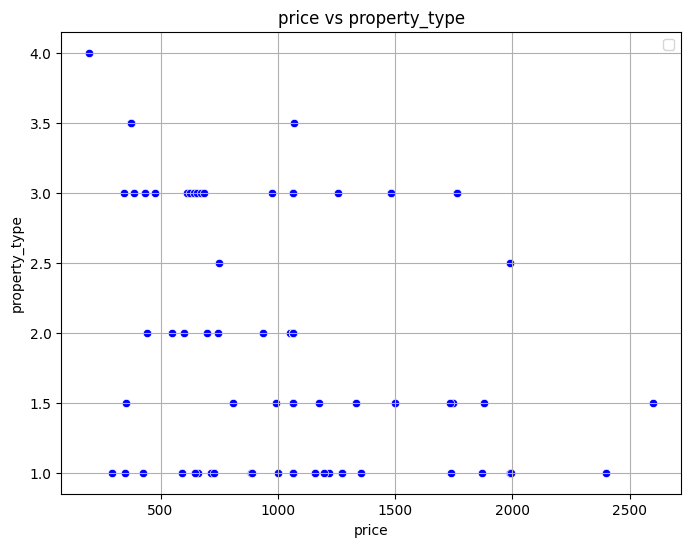

In [7]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='property_type', x='price',  color = 'blue', data=df)
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
indep= df[['property_type']]
dep = df[['price']]

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [11]:
model.fit(indep, dep)

LinearRegression()

In [12]:
type(model)

sklearn.linear_model._base.LinearRegression

In [13]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-106.01662799]]),
 'rank_': 1,
 'singular_': array([9.73652916]),
 'intercept_': array([1317.44851723])}

In [14]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-106.01662799]]
Intercepto: [1317.44851723]
y = [-106.01662799]x + [1317.44851723]


In [15]:
r2 = model.score(indep, dep)
r2

0.04542128811601098

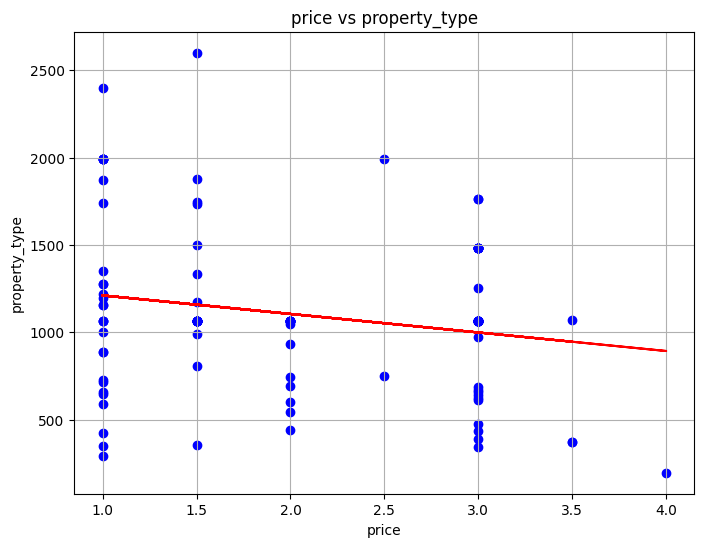

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(indep, dep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.grid(True)
plt.show()

In [18]:
yPred = model.predict(df[['property_type']])
yPred

array([[1211.43188924],
       [1158.42357525],
       [1158.42357525],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1105.41526125],
       [1211.43188924],
       [1211.43188924],
       [1105.41526125],
       [1211.43188924],
       [1211.43188924],
       [1052.40694726],
       [1158.42357525],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1052.40694726],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1211.43188924],
       [1158.42357525],
       [1211.43188924],
       [1211.43188924],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [ 999.39863326],
       [1105.415

In [19]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
47,48,281134,196253,1,1,previous scrape,COOL PENT HOUSE APARTMENT @CONDESA,Amazing Pent House apartment in the heart fo C...,No neighborhood_overview,Fernando,...,0.0,4.71,4.71,5.00,5.00,5.00,5.00,4.86,0.06,1211.431889
61,62,1565220,2518152,1,1,previous scrape,Descansa en la Suite de la Abuelita San Angel ...,"Beautiful, spacious and calm independent Suite...",San Ángel is a XVI century village nestled in ...,Martha Laura,...,0.0,4.96,5.00,5.00,5.00,4.96,4.93,4.93,0.21,1158.423575
74,75,1736063,2518152,1,1,previous scrape,"Cómodo Estudio del Botánico, San Angel CDMX","Small, very practical and beautiful independen...",San Ángel is a XVI century village nestled in ...,Martha Laura,...,0.0,4.88,4.84,4.97,4.89,4.93,4.96,4.86,0.45,1158.423575
99,100,571166,196253,1,1,city scrape,MODERN/HIP FURNISHED APARTMENT ( S1 Condesa Haus),This is a one bedroom furnished apartment in t...,No neighborhood_overview,Fernando,...,0.0,4.00,5.00,5.00,5.00,4.90,5.00,4.00,0.01,1211.431889
134,135,737328,3850198,1,1,city scrape,Business Suite BEIGE near Reforma,No description,The area in which our service is located stand...,Hermann,...,0.0,4.84,4.88,4.84,5.00,5.00,4.84,4.80,0.18,1211.431889


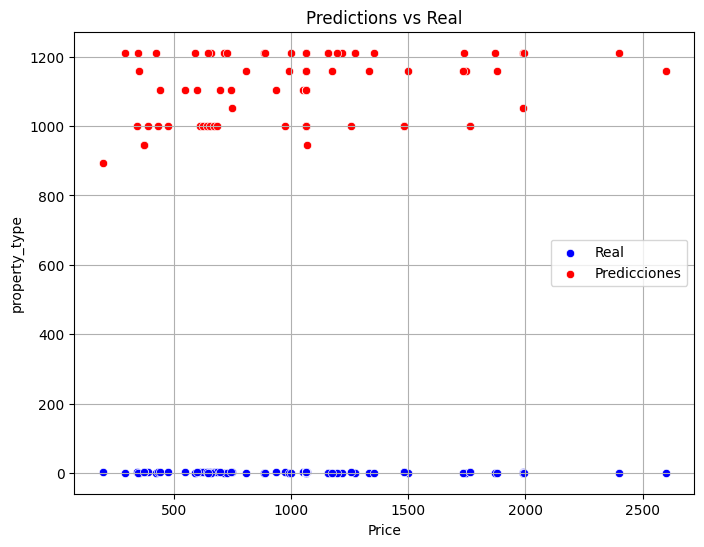

In [20]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='property_type', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
coefDe = model.score(indep, dep)
coefDe

0.04542128811601098

In [22]:
coefDe = model.score(indep, dep)
coefDe

0.04542128811601098

In [23]:
df = df[df['host_acceptance_rate'] != 'No data']
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

In [24]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_34012\1234139552.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


In [27]:
df['bathrooms_text'].head()

47     1 
61     1 
74     1 
99     1 
134    1 
Name: bathrooms_text, dtype: object

In [26]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('bath', '', regex=False)
#df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared', '', regex=False)


In [28]:
df = df.dropna(subset=['bathrooms_text'])
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')
df['bathrooms_text'] = df['bathrooms_text'].astype(float)

In [29]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)

C:\Users\issei\AppData\Local\Temp\ipykernel_34012\1014031884.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)


In [30]:
df['instant_bookable'] = df['instant_bookable'].replace({'t': 1, 'f': 0}).astype(int)

C:\Users\issei\AppData\Local\Temp\ipykernel_34012\4229115140.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].replace({'t': 1, 'f': 0}).astype(int)


In [31]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','review_scores_value','reviews_per_month','property_type']]

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 47 to 24859
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_acceptance_rate       87 non-null     float64
 1   host_is_superhost          87 non-null     float64
 2   price                      87 non-null     float64
 3   accommodates               87 non-null     float64
 4   bathrooms_text             67 non-null     float64
 5   review_scores_cleanliness  87 non-null     float64
 6   host_identity_verified     87 non-null     int32  
 7   instant_bookable           87 non-null     int32  
 8   host_total_listings_count  87 non-null     float64
 9   review_scores_value        87 non-null     float64
 10  reviews_per_month          87 non-null     float64
 11  property_type              87 non-null     float64
dtypes: float64(10), int32(2)
memory usage: 8.2 KB


In [33]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.239727,0.069318,-0.000735,NaN,0.001521,-0.123560,-0.025561,-0.012150,0.015942,0.120154,0.122154
host_is_superhost,0.239727,1.000000,-0.051005,0.067865,NaN,-0.162644,0.220085,-0.212480,0.067809,-0.341890,-0.192273,0.145056
price,0.069318,-0.051005,1.000000,-0.078246,NaN,0.273124,-0.150441,-0.146275,0.061858,-0.075323,0.021934,-0.358094
accommodates,-0.000735,0.067865,-0.078246,1.000000,NaN,-0.130987,-0.364402,0.208913,0.050519,-0.114727,0.259719,0.194145
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.001521,-0.162644,0.273124,-0.130987,NaN,1.000000,0.029355,-0.198499,-0.130635,0.481864,-0.062675,-0.544714
host_identity_verified,-0.123560,0.220085,-0.150441,-0.364402,NaN,0.029355,1.000000,-0.151083,0.159696,-0.043748,-0.804484,-0.412725
instant_bookable,-0.025561,-0.212480,-0.146275,0.208913,NaN,-0.198499,-0.151083,1.000000,0.264024,-0.019565,0.044624,0.429730
host_total_listings_count,-0.012150,0.067809,0.061858,0.050519,NaN,-0.130635,0.159696,0.264024,1.000000,-0.126969,-0.211044,-0.035053
review_scores_value,0.015942,-0.341890,-0.075323,-0.114727,NaN,0.481864,-0.043748,-0.019565,-0.126969,1.000000,0.100137,-0.186865


In [34]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.239727,0.069318,0.000735,NaN,0.001521,0.123560,0.025561,0.012150,0.015942,0.120154,0.122154
host_is_superhost,0.239727,1.000000,0.051005,0.067865,NaN,0.162644,0.220085,0.212480,0.067809,0.341890,0.192273,0.145056
price,0.069318,0.051005,1.000000,0.078246,NaN,0.273124,0.150441,0.146275,0.061858,0.075323,0.021934,0.358094
accommodates,0.000735,0.067865,0.078246,1.000000,NaN,0.130987,0.364402,0.208913,0.050519,0.114727,0.259719,0.194145
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.001521,0.162644,0.273124,0.130987,NaN,1.000000,0.029355,0.198499,0.130635,0.481864,0.062675,0.544714
host_identity_verified,0.123560,0.220085,0.150441,0.364402,NaN,0.029355,1.000000,0.151083,0.159696,0.043748,0.804484,0.412725
instant_bookable,0.025561,0.212480,0.146275,0.208913,NaN,0.198499,0.151083,1.000000,0.264024,0.019565,0.044624,0.429730
host_total_listings_count,0.012150,0.067809,0.061858,0.050519,NaN,0.130635,0.159696,0.264024,1.000000,0.126969,0.211044,0.035053
review_scores_value,0.015942,0.341890,0.075323,0.114727,NaN,0.481864,0.043748,0.019565,0.126969,1.000000,0.100137,0.186865


C:\Users\issei\AppData\Roaming\Python\Python312\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


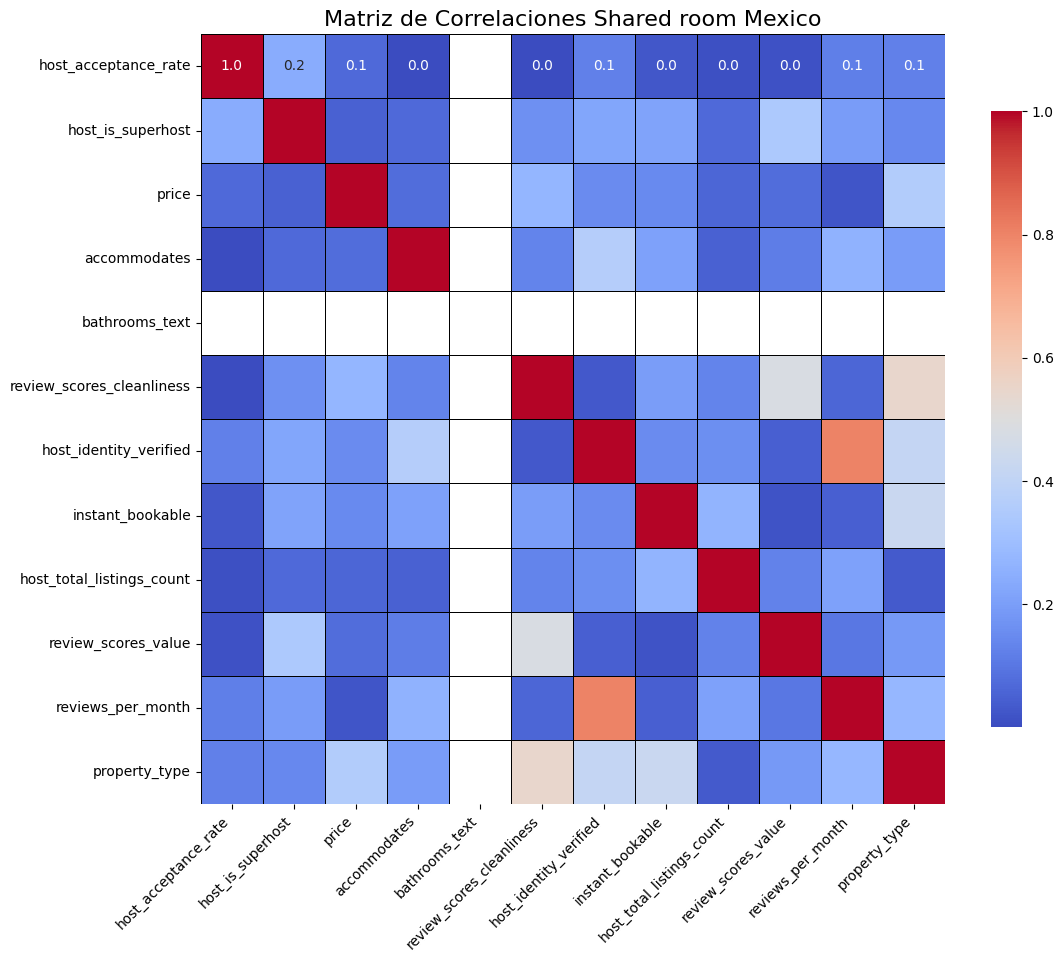

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Shared room Mexico', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()